In [1]:
import os


os.environ["RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO"] = "0"
os.environ["RAY_DEDUP_LOGS"] = "1"

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from starforge.blackholes.parameters_recover.parameters_recovery import ParametersRecoveryRemote

from starforge.blackholes.parameters_recover.metrics import (
    nrmse_percent,
    smape_percent,
    stabilized_mape_percent,
)

from starforge.blackholes.accretionrate.blackholesaccretionrate import ParameterAccretionRate
from starforge.blackholes.parameters_recover.utils import add_noise_to_data, gaussian_sum_from_p
from starforge.blackholes.parameters_recover.utils import make_bounds_for_gaussians
from starforge.blackholes.parameters_recover.schemes import GridParameters
import ray

In [3]:
import pandas as pd

In [4]:
if ray.is_initialized() is False:
    ray.init(ignore_reinit_error=True)

2026-05-26 07:30:43,674	INFO worker.py:2004 -- Started a local Ray instance. View the dashboard at http://127.0.0.1:8265 


In [5]:
mbh_steps = 25

grid_params = GridParameters(
    mbh_steps=mbh_steps,
    z_steps=mbh_steps*100
)

ln_mbh_grid = np.linspace(
    grid_params.mbh_i,
    grid_params.mbh_f,
    grid_params.mbh_steps
)

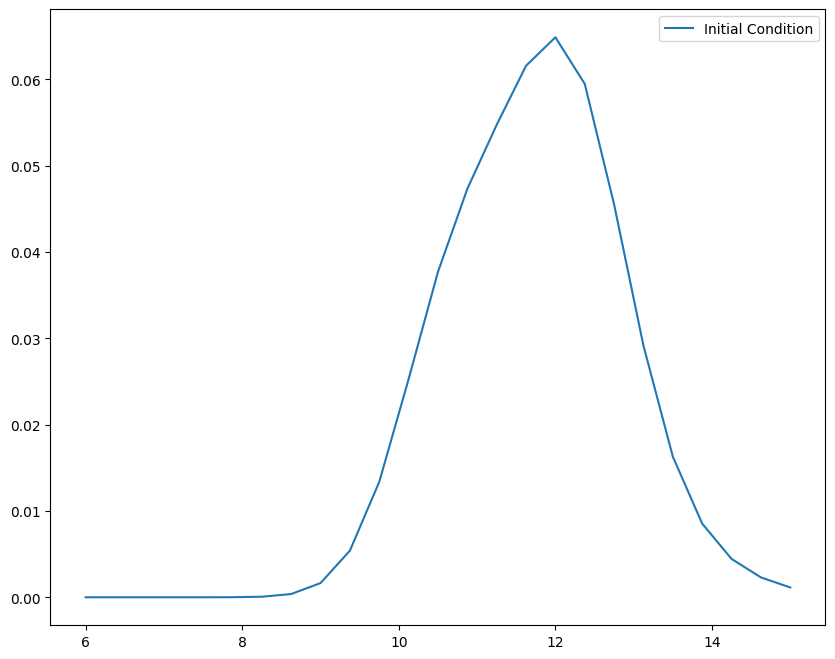

In [6]:
parameters_observational = np.array([
        3.3e-02,
        8.2e-03,
        5.4e-02,
        1.07e+01,
        1.29e+01,
        1.21e+01,
        6.93e-01,
        1.05e+00,
        7.47e-01
    ])


initial_condition = gaussian_sum_from_p(
        parameters_observational,
        ln_mbh_grid,
        n_gauss=3
    )

plt.figure(figsize=(10,8))
plt.plot(ln_mbh_grid, initial_condition, label="Initial Condition")
# plt.yscale("log")
plt.legend()
plt.show()
plt.close()

In [7]:
objective_function = ParametersRecoveryRemote.remote(
    grid_params=grid_params)

accretion_params = ParameterAccretionRate(
    mbh_par=2e11,
    alpha_par=3e-1,
    tau_par=5e9,
    eta=0.1,
    t_q=1e9,
    b_1=0.1,
    b_2=0.1,
)


# ---- Generate target data ----

outputs = ray.get(
    objective_function.directly_problem.remote(
        initial_condition,
        accretion_params
    )
)


In [8]:
# Noise levels to evaluate
noise_levels = [0.01, 0.03, 0.05, 0.1]

# Dictionary to store all runs
results = {}

Running optimization with noise level: 0.01
(ParametersRecovery pid=3037559) Starting optimization ...
(ParametersRecovery pid=3037559) Objective value: 1.422913e+02 | Context: Minimum detected in annealing process


(ParametersRecovery pid=3037559) /home/eduardo/Projects/starforge2/.venv/lib/python3.12/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
(ParametersRecovery pid=3037559)   df = [f_eval - f0 for f_eval in f_evals]


(ParametersRecovery pid=3037559) Objective value: 1.420168e+02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=3037559) Objective value: 1.361994e+02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=3037559) Objective value: 1.312749e+02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=3037559) Objective value: 1.224037e+02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=3037559) Objective value: 9.162196e+01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=3037559) Objective value: 9.116729e+01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=3037559) Objective value: 8.995390e+01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=3037559) Objective value: 8.973092e+01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=3037559) Objective value: 8.972866e+01 | Context: Minimum detected in annealing 

(ParametersRecovery pid=3037559) /home/eduardo/Projects/starforge2/src/starforge/blackholes/parameters_recover/parameters_recovery.py:230: RuntimeWarning: invalid value encountered in log10
(ParametersRecovery pid=3037559)   normalization_model = np.log10(params_array[-n:] + epsilon)


(ParametersRecovery pid=3037559) Objective value: 7.402173e+00 | Context: Minimum detected in annealing process
(ParametersRecovery pid=3037559) Objective value: 7.400401e+00 | Context: Minimum detected in annealing process
(ParametersRecovery pid=3037559) Objective value: 6.854790e+00 | Context: Detection occurred in local search
(ParametersRecovery pid=3037559) Objective value: 6.837459e+00 | Context: Minimum detected in annealing process
(ParametersRecovery pid=3037559) Objective value: 6.586884e+00 | Context: Detection occurred in local search
(ParametersRecovery pid=3037559) Objective value: 6.585545e+00 | Context: Minimum detected in annealing process
(ParametersRecovery pid=3037559) Objective value: 6.585189e+00 | Context: Detection occurred in local search
(ParametersRecovery pid=3037559) Objective value: 6.584075e+00 | Context: Minimum detected in annealing process
(ParametersRecovery pid=3037559) Objective value: 6.582876e+00 | Context: Minimum detected in annealing process
(

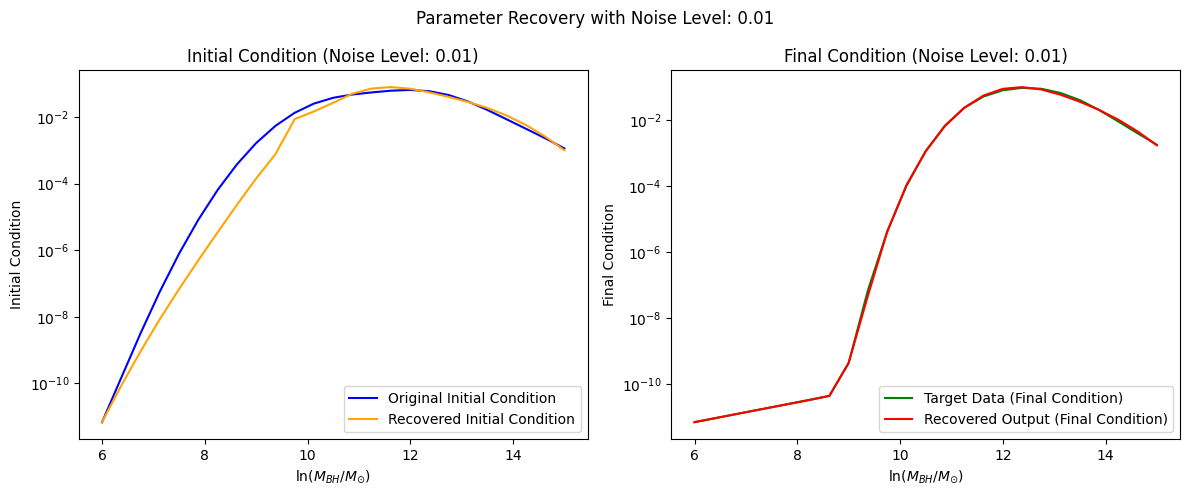

Running optimization with noise level: 0.03
(ParametersRecovery pid=3037559) Starting optimization ...
(ParametersRecovery pid=3037559) Objective value: 1.440365e+02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=3037559) Objective value: 1.376724e+02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=3037559) Objective value: 1.373939e+02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=3037559) Objective value: 1.183755e+02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=3037559) Objective value: 1.180278e+02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=3037559) Objective value: 1.073288e+02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=3037559) Objective value: 9.855234e+01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=3037559) Objective value: 9.579364e+01 | Context: Minimum detected in annealing process
(

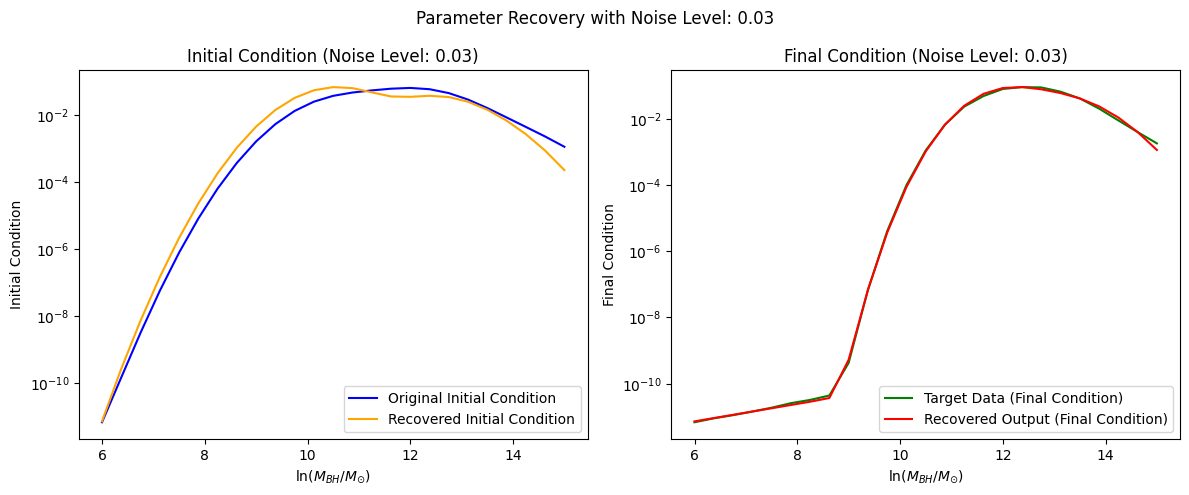

Running optimization with noise level: 0.05
(ParametersRecovery pid=3037559) Starting optimization ...
(ParametersRecovery pid=3037559) Objective value: 1.468652e+02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=3037559) Objective value: 1.429547e+02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=3037559) Objective value: 1.363666e+02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=3037559) Objective value: 1.281580e+02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=3037559) Objective value: 1.263108e+02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=3037559) Objective value: 1.262360e+02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=3037559) Objective value: 1.212637e+02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=3037559) Objective value: 1.152352e+02 | Context: Detection occurred in local search
(Par

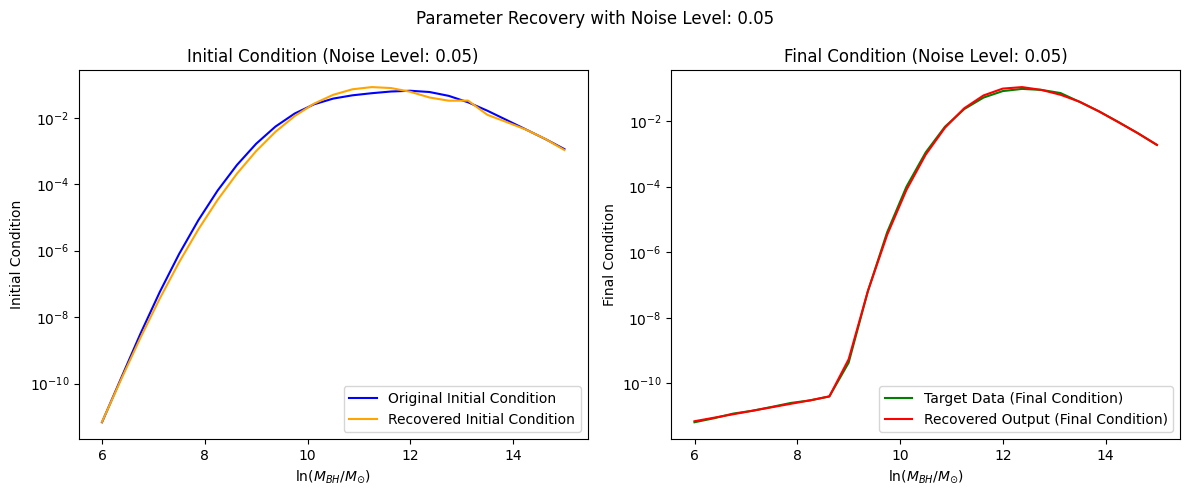

Running optimization with noise level: 0.10
(ParametersRecovery pid=3037559) Starting optimization ...
(ParametersRecovery pid=3037559) Objective value: 1.584816e+02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=3037559) Objective value: 1.487757e+02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=3037559) Objective value: 1.174265e+02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=3037559) Objective value: 1.171623e+02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=3037559) Objective value: 1.168514e+02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=3037559) Objective value: 1.088608e+02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=3037559) Objective value: 7.334327e+01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=3037559) Objective value: 7.305728e+01 | Context: Minimum detected in annealing process
(

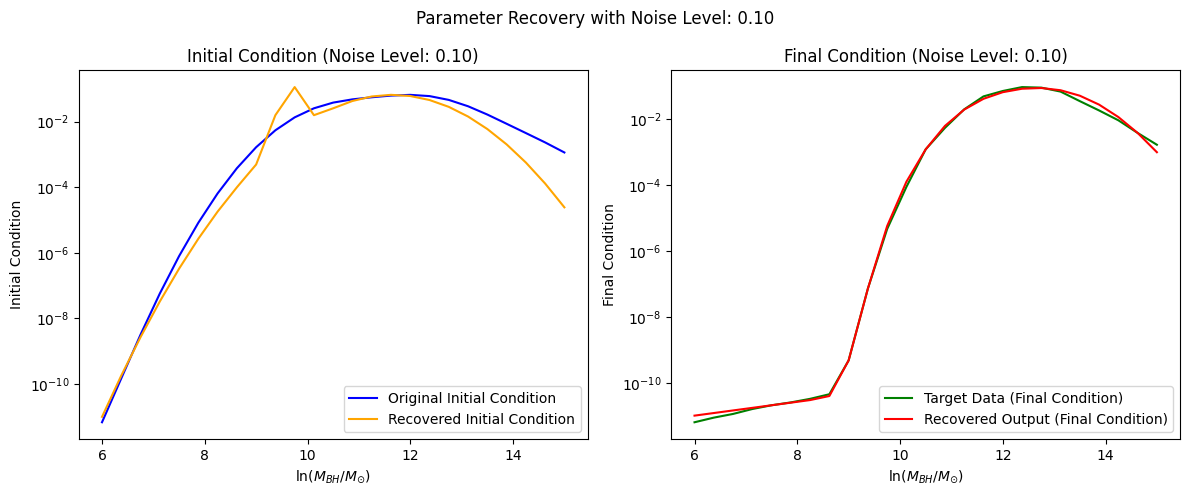

In [9]:
# ---- Define bounds for optimization ----

bounds = make_bounds_for_gaussians(
    x_min=6.0,
    x_max=15.0,
    preferred_center_index=2,
    preferred_center=12.0,
    preferred_center_radius=1.0,
    Amax=1e-1,
    sigma_min=0.01,
    sigma_max=5.0,
    sigma_max_preferred=1.0,
    K=3
)


bounds.extend([  # For eta, tau_par, alpha_par
    (0.5, 5.0),     # mbh_par
    (1.0, 10.0),   # tau_par Gyr
    (0.01, 0.6),    # alpha_par
    (0.01, 0.5),    # eta
    (0.5, 5.0),    # t_q Gyr
    (0.01, 0.5),   # b_1
    (0.01, 0.5)    # b_2
])


MODEL_PARAM_COUNT = 7


# %%
# =====================================================
# Generate LaTeX Table with Recovered Parameters
# =====================================================

def format_sci(x):
    """Format number in LaTeX scientific notation."""
    exponent = int(np.floor(np.log10(abs(x)))) if x != 0 else 0
    mantissa = x / (10 ** exponent) if x != 0 else 0
    return rf"${mantissa:.2f}\times10^{{{exponent}}}$"


# Original parameters
original_params = {
    r"$A_{0}\,[{\rm dex}^{-1}]$": parameters_observational[0],
    r"$\mu_{0}$": parameters_observational[1],
    r"$\sigma_{0}$": parameters_observational[2],

    r"$A_{1}\,[{\rm dex}^{-1}]$": parameters_observational[3],
    r"$\mu_{1}$": parameters_observational[4],
    r"$\sigma_{1}$": parameters_observational[5],

    r"$A_{2}\,[{\rm dex}^{-1}]$": parameters_observational[6],
    r"$\mu_{2}$": parameters_observational[7],
    r"$\sigma_{2}$": parameters_observational[8],

    r"$m_{bh}^{*}\,[{\rm M}_{\odot}]$": 2.0,
    r"$\tau^{*}\,[{\rm Gyr}]$": 5.0,
    r"$\alpha$": 3e-1,
    r"$\bar{\eta}^{0}$": 1e-1,
    r"$t_q\,[{\rm Gyr}]$": 1.0,
    r"$b_{1}$": 1e-1,
    r"$b_{2}$": 1e-1,
}


# Store recovered parameters
recovered_table = {}

for i, noise_level in enumerate(noise_levels):

    print(f"Running optimization with noise level: {noise_level:.2f}")

    target_data = add_noise_to_data(
        data=outputs.n_final,
        mu=0.0,
        sigma=noise_level,
        rho=0.5,
        alpha=0.5,
        seed=52+i,
        noise_type='mixed'
    )
    # -------------------------------------------------
    
    result = ray.get(
        objective_function.optimizer.remote(
            bounds=bounds,
            target_data=target_data,
            weight_p=0.1,
            weight_theta=0.1,
            fast_mode=False,
            use_de=True
        )
    )

    best_params = result.x

    gaussian_parameters = best_params[:-MODEL_PARAM_COUNT]
    model_parameters = best_params[-MODEL_PARAM_COUNT:]

    recovered_values = [
        gaussian_parameters[0],
        gaussian_parameters[1],
        gaussian_parameters[2],

        gaussian_parameters[3],
        gaussian_parameters[4],
        gaussian_parameters[5],

        gaussian_parameters[6],
        gaussian_parameters[7],
        gaussian_parameters[8],

        model_parameters[0],  # mbh_par in units of 1e11 Msun
        model_parameters[1],  # tau_par in Gyr
        model_parameters[2],  # alpha
        model_parameters[3],  # eta
        model_parameters[4],  # t_q in Gyr
        model_parameters[5],  # b1
        model_parameters[6],  # b2
    ]

    recovered_table[noise_level] = recovered_values


    initial_condition_recovered = gaussian_sum_from_p(
            gaussian_parameters,
            ln_mbh_grid,
            n_gauss=3
        )  

    # Build physical model parameters
    accretion_params_recovered = ParameterAccretionRate(
        mbh_par=model_parameters[0] * 1e11,
        tau_par=model_parameters[1] * 1e9,
        alpha_par=model_parameters[2],

        eta=model_parameters[3],
        t_q=model_parameters[4] * 1e9,
        b_1=model_parameters[5],
        b_2=model_parameters[6]
    )

    # ---- Generate target data ----

    outputs_recovery = ray.get(
        objective_function.directly_problem.remote(
            initial_condition_recovered,
            accretion_params_recovered
        )
    )

    # -------------------------------------------------

    recovered_initial_condition = initial_condition_recovered

    recovered_output = outputs_recovery.n_final

    target_data = np.clip(target_data, 1e-30, None)
    recovered_output = np.clip(recovered_output, 1e-30, None)
    recovered_initial_condition = np.clip(
        recovered_initial_condition,
        1e-30,
        None
    )

    # -------------------------------------------------
    # Initial Condition Metrics
    # -------------------------------------------------

    nrmse_init = nrmse_percent(
        initial_condition,
        recovered_initial_condition,
        denom='mean'
    )

    s_mape_init = smape_percent(
        initial_condition,
        recovered_initial_condition,
        eps=1e-12
    )

    stab_mape_init = stabilized_mape_percent(
        initial_condition,
        recovered_initial_condition,
        eps=1e-8
    )

    # -------------------------------------------------
    # Final Condition Metrics
    # -------------------------------------------------

    nrmse = nrmse_percent(
        target_data,
        recovered_output,
        denom='mean'
    )

    s_mape = smape_percent(
        target_data,
        recovered_output,
        eps=1e-12
    )

    stab_mape = stabilized_mape_percent(
        target_data,
        recovered_output,
        eps=1e-8
    )

    # -------------------------------------------------
    # Metrics text
    # -------------------------------------------------

    metrics_text_init = (
        f'NRMSE={nrmse_init:.2f}%\n'
        f'sMAPE={s_mape_init:.2f}%\n'
        f'MAPE*={stab_mape_init:.2f}%'
    )

    metrics_text = (
        f'NRMSE={nrmse:.2f}%\n'
        f'sMAPE={s_mape:.2f}%\n'
        f'MAPE*={stab_mape:.2f}%'
    )

    # -------------------------------------------------
    # Store results
    # -------------------------------------------------

    results[noise_level] = {
        "ln_mbh_grid": ln_mbh_grid,
        "initial_condition": initial_condition,
        "initial_condition_recovered": recovered_initial_condition,
        "outputs_n_final": recovered_output,
        "target_data": target_data,
        "metrics": metrics_text,
        "metrics_init": metrics_text_init,
        "grid_params": grid_params,
    }
    
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(ln_mbh_grid, initial_condition, label="Original Initial Condition", color='blue')
    plt.plot(ln_mbh_grid, recovered_initial_condition, label="Recovered Initial Condition", color='orange')
    plt.title(f"Initial Condition (Noise Level: {noise_level:.2f})")
    plt.xlabel(r"$\ln(M_{BH}/M_{\odot})$")
    plt.ylabel("Initial Condition")
    plt.yscale("log")
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(ln_mbh_grid, target_data, label="Target Data (Final Condition)", color='green')
    plt.plot(ln_mbh_grid, recovered_output, label="Recovered Output (Final Condition)", color='red')
    plt.title(f"Final Condition (Noise Level: {noise_level:.2f})")
    plt.xlabel(r"$\ln(M_{BH}/M_{\odot})$")
    plt.ylabel("Final Condition")
    plt.yscale("log")
    plt.legend()
    plt.suptitle(f"Parameter Recovery with Noise Level: {noise_level:.2f}")
    plt.tight_layout()
    plt.show()
    plt.close()

In [10]:
for i, noise in enumerate(sorted(results.keys())):
    df = pd.DataFrame({
        "ln_mbh_grid": results[noise]["ln_mbh_grid"],
        "initial_condition": results[noise]["initial_condition"],
        "initial_condition_recovered": results[noise]["initial_condition_recovered"],
        "outputs_n_final": results[noise]["outputs_n_final"],
        "target_data": results[noise]["target_data"],
        "metrics": results[noise]["metrics"],
        "metrics_init": results[noise]["metrics_init"],
    })
    df.to_csv(f"./results/parameters_recovery_results_noise_{noise:.2f}.csv", index=False)

In [11]:
# Optional: article-style plotting configuration
plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 16,
    "legend.fontsize": 11,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "lines.linewidth": 2,
    "axes.grid": True,
})

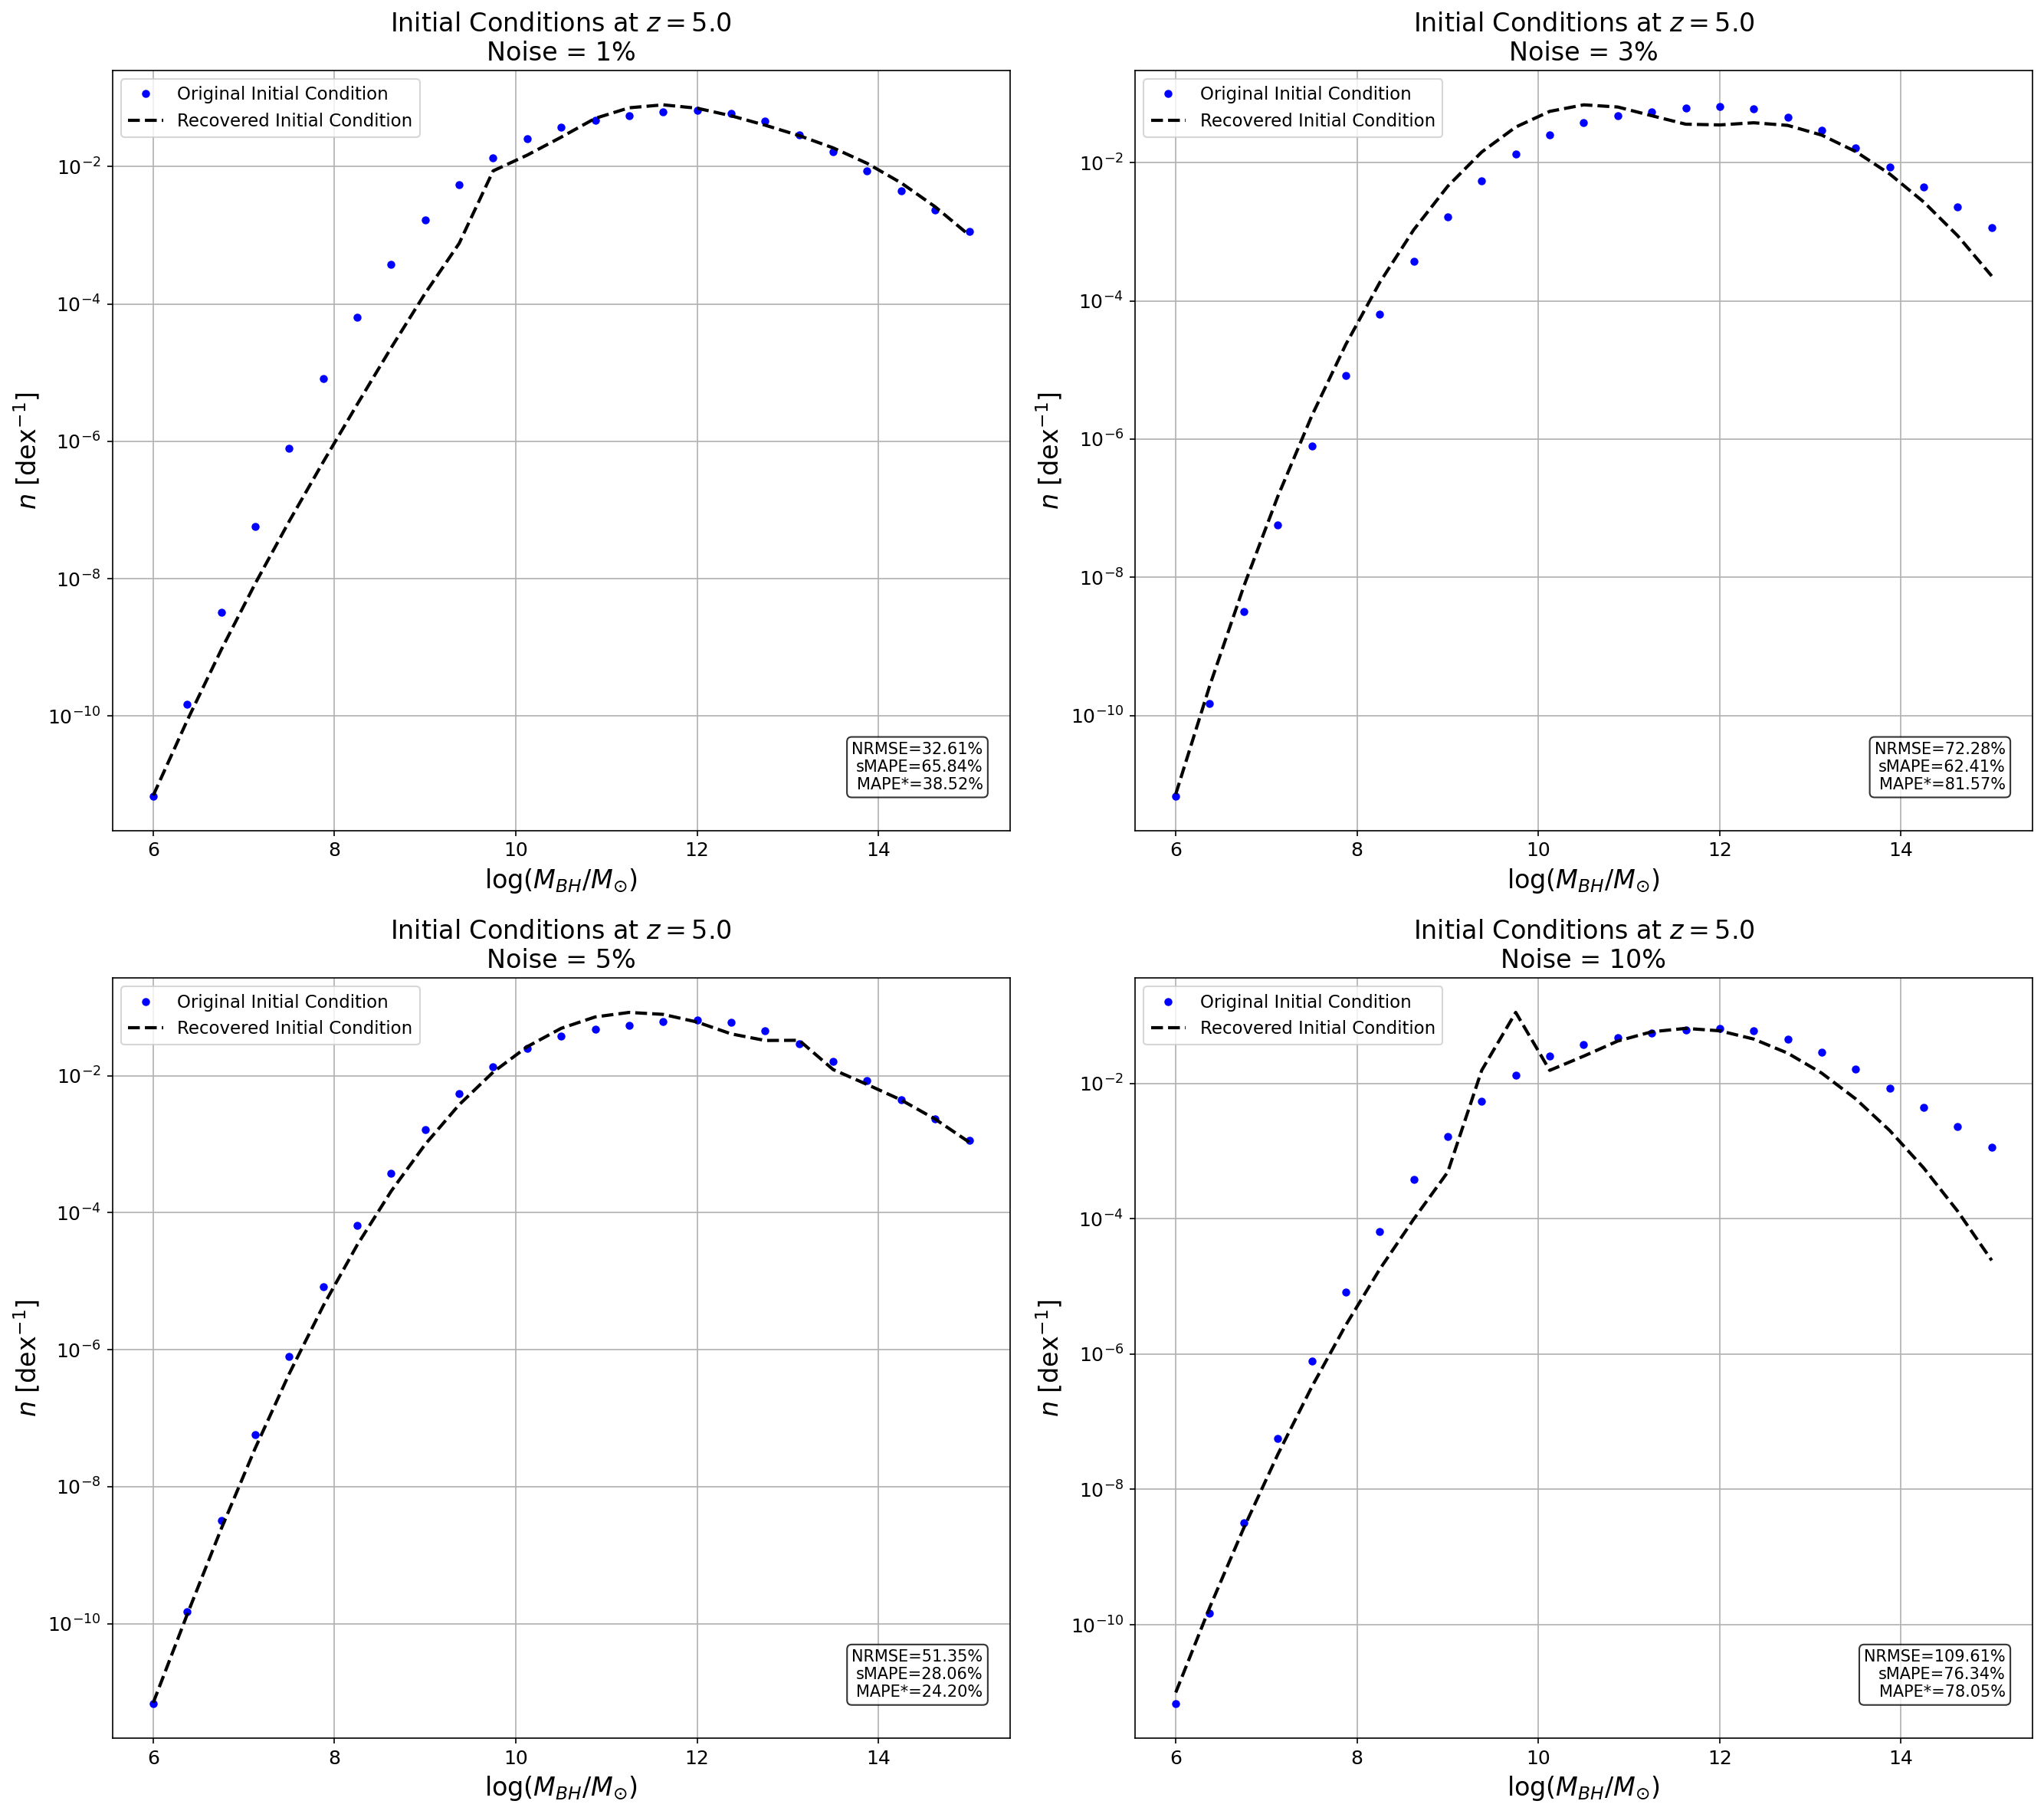

In [12]:
# =====================================================
# Initial Conditions Comparison
# =====================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 16))

axes = axes.flatten()

for i, noise in enumerate(sorted(results.keys())):

    ax = axes[i]
    res = results[noise]

    ax.plot(
        res['ln_mbh_grid'],
        res['initial_condition'],
        marker='o',
        markersize=4,
        linestyle='None',
        label='Original Initial Condition',
        color='blue'
    )

    ax.plot(
        res['ln_mbh_grid'],
        res['initial_condition_recovered'],
        '--',
        label='Recovered Initial Condition',
        color='black'
    )

    ax.set_yscale('log')

    ax.set_xlabel(r'$\log(M_{BH} / M_{\odot})$')
    ax.set_ylabel(r'$n$ [dex$^{-1}$]')

    ax.text(
        0.97,
        0.05,
        res['metrics_init'],
        transform=ax.transAxes,
        fontsize=10,
        va='bottom',
        ha='right',
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="white",
            alpha=0.8
        )
    )

    ax.set_title(
        rf'Initial Conditions at $z = {res["grid_params"].z_i}$'
        '\n'
        rf'Noise = {noise*100:.0f}%'
    )

    ax.legend()

plt.tight_layout()

# Optional:
plt.savefig("./images/initial_condition_noise.png", bbox_inches="tight")

plt.show()

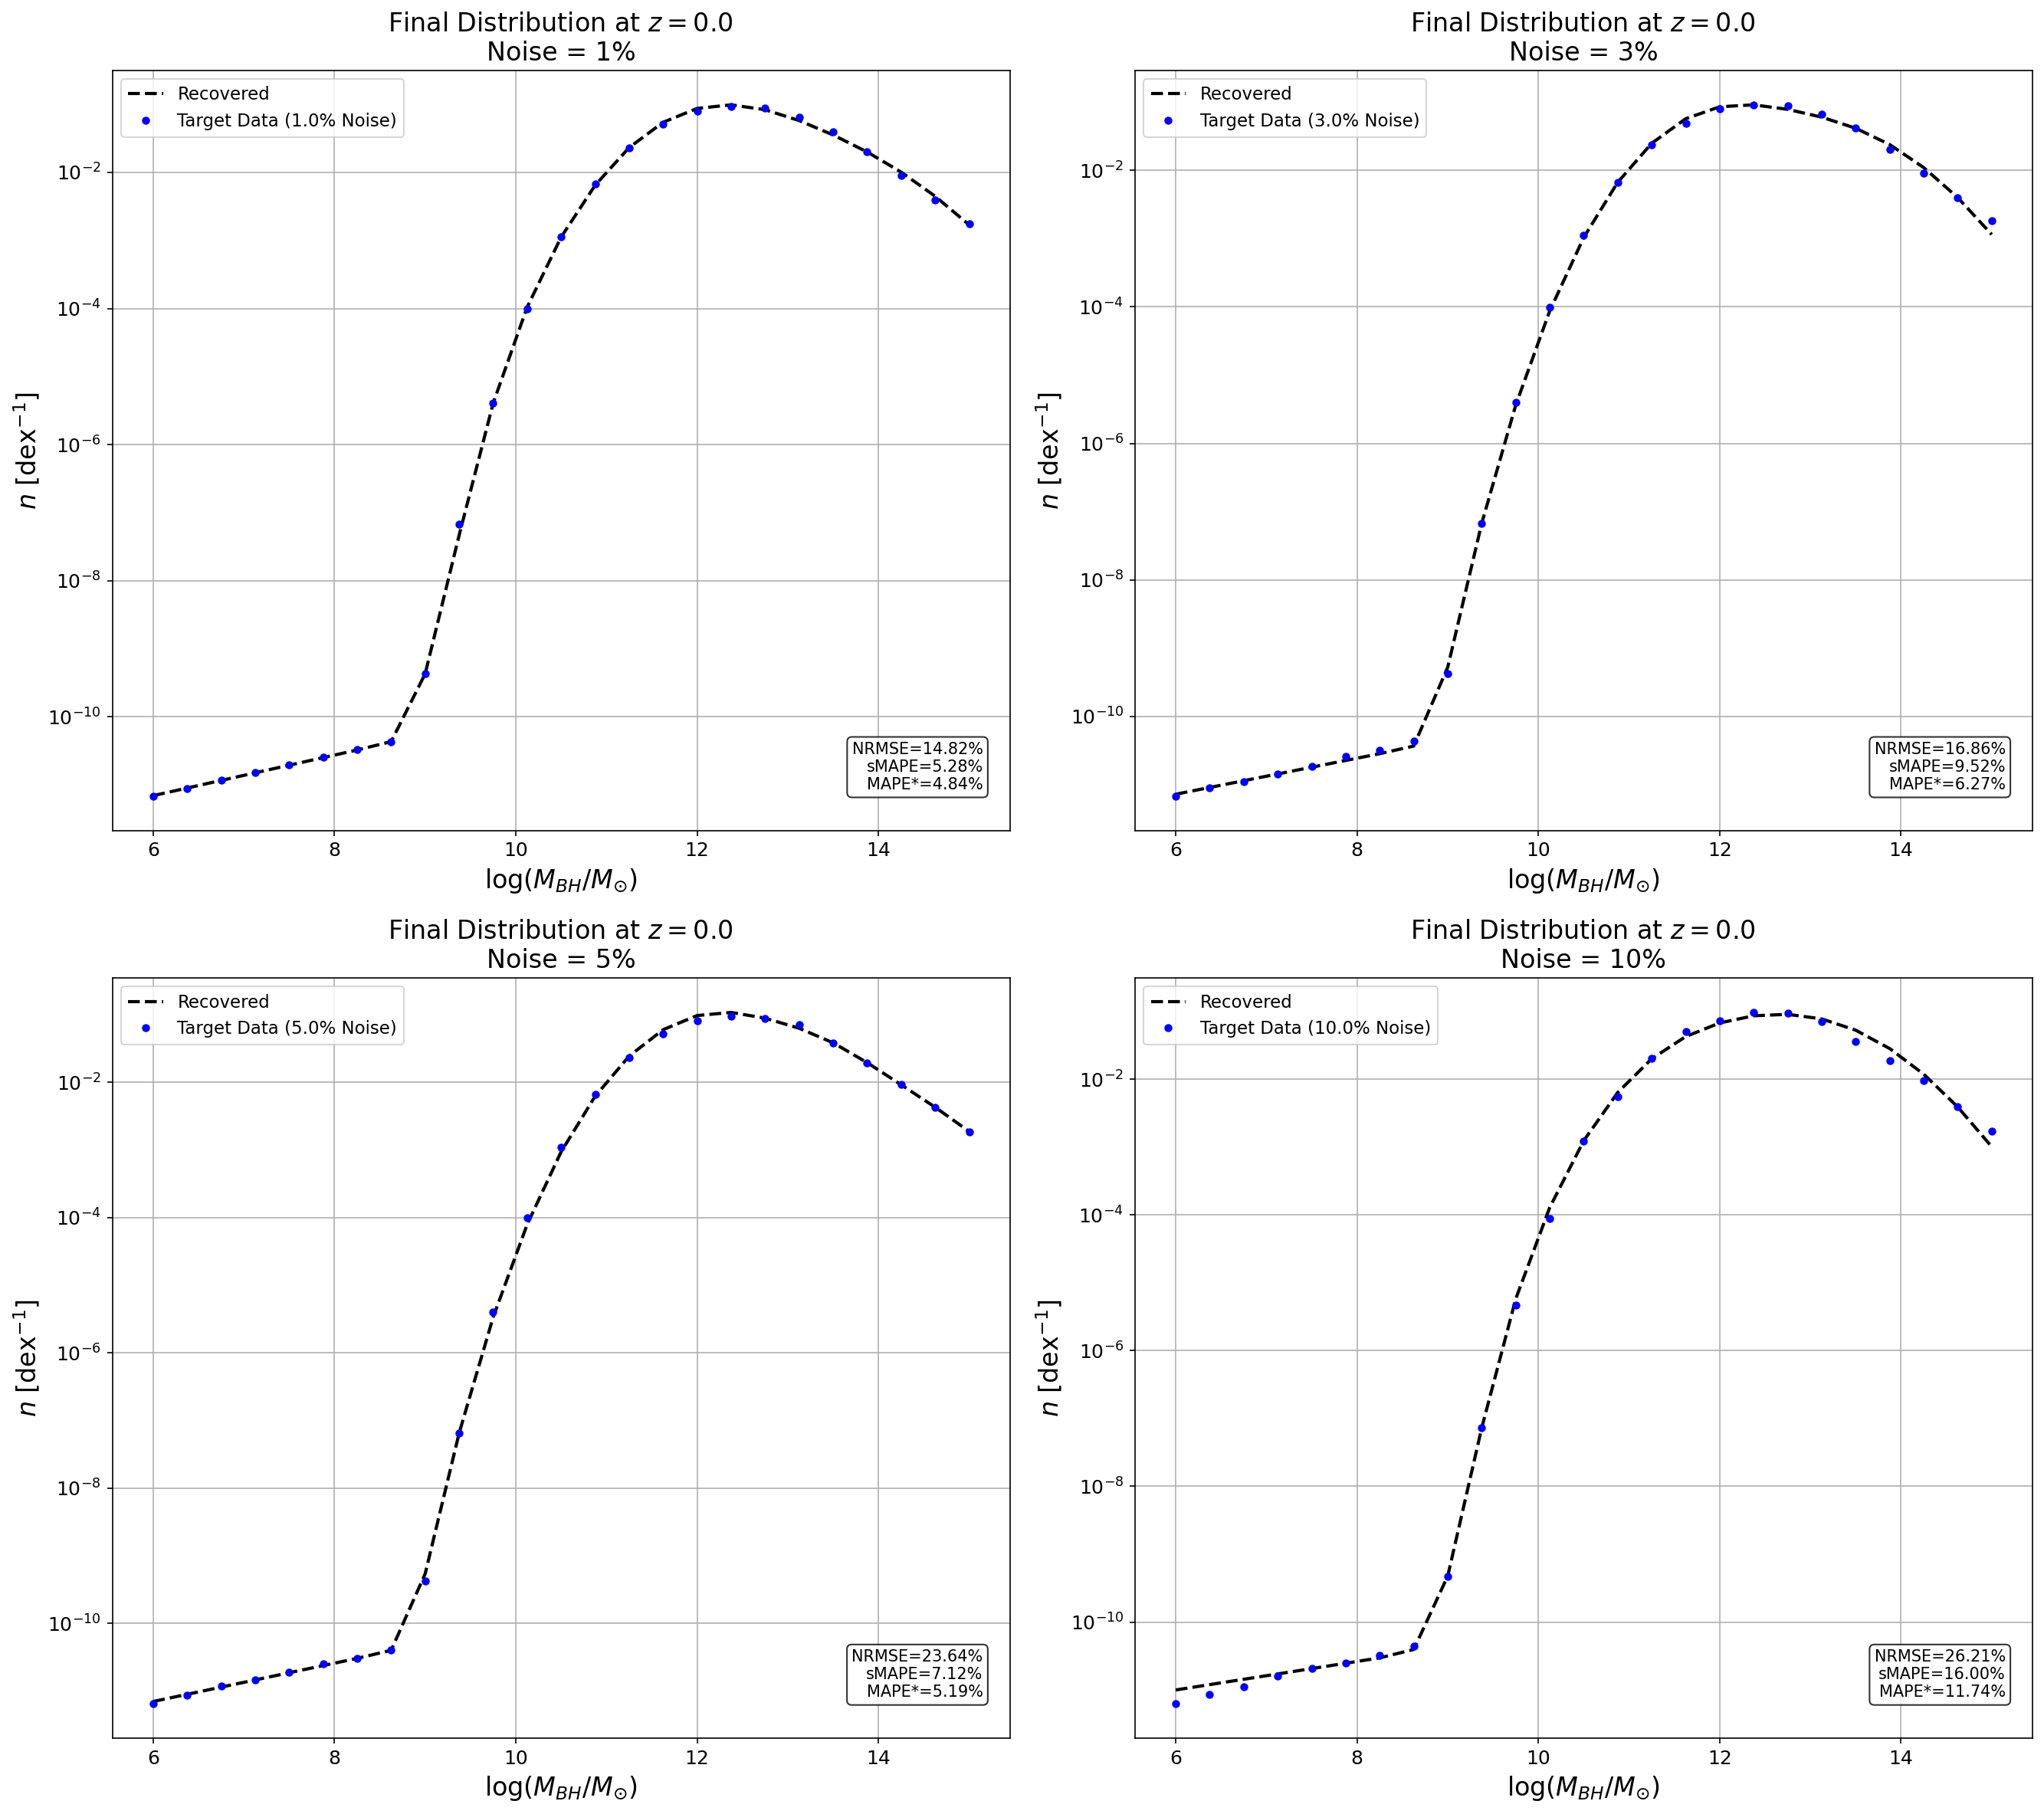

In [13]:
# =====================================================
# Final Data Comparison
# =====================================================

fig2, axes2 = plt.subplots(2, 2, figsize=(18, 16))

axes2 = axes2.flatten()

for i, noise in enumerate(sorted(results.keys())):

    ax2 = axes2[i]
    res = results[noise]

    ax2.plot(
        res['ln_mbh_grid'],
        res['outputs_n_final'],
        '--',
        label='Recovered',
        color='black'
    )

    ax2.plot(
        res['ln_mbh_grid'],
        res['target_data'],
        marker='o',
        markersize=4,
        linestyle='None',
        label=rf'Target Data ({noise*100:.1f}% Noise)',
        color='blue'
    )

    ax2.set_yscale('log')

    ax2.set_xlabel(r'$\log(M_{BH} / M_{\odot})$')
    ax2.set_ylabel(r'$n$ [dex$^{-1}$]')

    ax2.text(
        0.97,
        0.05,
        res['metrics'],
        transform=ax2.transAxes,
        fontsize=10,
        va='bottom',
        ha='right',
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="white",
            alpha=0.8
        )
    )

    ax2.set_title(
        rf'Final Distribution at $z = {res["grid_params"].z_f}$ '
        '\n'
        rf'Noise = {noise*100:.0f}%'
    )

    ax2.legend()

plt.tight_layout()

# Optional:
plt.savefig("./images/integrated_result.png", bbox_inches="tight")

plt.show()

In [14]:
parameter_names = list(original_params.keys())

# -----------------------------------------------------
# Build LaTeX table
# -----------------------------------------------------

latex_table = []

latex_table.append(r"\begin{table*}[h!]")
latex_table.append(r"\centering")
latex_table.append(r"\small")
latex_table.append(r"\begin{tabular}{lccccc}")
latex_table.append(r"\hline")

latex_table.append(
    r"\textbf{Parameter} & "
    r"\textbf{Orig.} & "
    r"\textbf{1\%} & "
    r"\textbf{3\%} & "
    r"\textbf{5\%} & "
    r"\textbf{10\%} \\"
)

latex_table.append(r"\hline")

for i, pname in enumerate(parameter_names):

    row = [pname]

    # Original value
    row.append(format_sci(list(original_params.values())[i]))

    # Noise columns
    for noise in sorted(recovered_table.keys()):
        row.append(format_sci(recovered_table[noise][i]))

    latex_table.append(" & ".join(row) + r" \\")

latex_table.append(r"\hline")
latex_table.append(r"\end{tabular}")

latex_table.append(
r"""
\caption{
Original parameter values and values recovered for different noise levels in the present-day data. 
The quantities $A_i$ are expressed in ${\rm dex}^{-1}$, while $m_{bh}^{*}$ is given in solar masses and 
$\tau^{*}$ and $t_q$ are given in Gyr. Parameters without explicit units are dimensionless. 
The Gaussian mixture parameters $\mu_i$ and $\sigma_i$, as well as the evolution parameters 
$\alpha$, $\bar{\eta}^{0}$, and $b_i$, are dimensionless quantities defined in the normalized 
variables of the model. The columns list the original parameter values and those recovered from 
present-day data contaminated with 1\%, 3\%, 5\%, and 10\% noise levels.
}
"""
)

latex_table.append(r"\label{tab:params_recovered}")
latex_table.append(r"\end{table*}")

latex_output = "\n".join(latex_table)

# -----------------------------------------------------
# Save table
# -----------------------------------------------------

os.makedirs("./tables", exist_ok=True)

with open("./tables/parameters_recovered_table.tex", "w") as f:
    f.write(latex_output)

print(latex_output)

\begin{table*}[h!]
\centering
\small
\begin{tabular}{lccccc}
\hline
\textbf{Parameter} & \textbf{Orig.} & \textbf{1\%} & \textbf{3\%} & \textbf{5\%} & \textbf{10\%} \\
\hline
$A_{0}\,[{\rm dex}^{-1}]$ & $3.30\times10^{-2}$ & $3.28\times10^{-2}$ & $1.45\times10^{-2}$ & $1.82\times10^{-2}$ & $2.08\times10^{-2}$ \\
$\mu_{0}$ & $8.20\times10^{-3}$ & $2.06\times10^{-2}$ & $6.87\times10^{-2}$ & $1.39\times10^{-2}$ & $9.15\times10^{-2}$ \\
$\sigma_{0}$ & $5.40\times10^{-2}$ & $5.85\times10^{-2}$ & $2.37\times10^{-2}$ & $7.88\times10^{-2}$ & $6.50\times10^{-2}$ \\
$A_{1}\,[{\rm dex}^{-1}]$ & $1.07\times10^{1}$ & $1.24\times10^{1}$ & $1.28\times10^{1}$ & $1.30\times10^{1}$ & $9.64\times10^{0}$ \\
$\mu_{1}$ & $1.29\times10^{1}$ & $9.93\times10^{0}$ & $1.06\times10^{1}$ & $1.27\times10^{1}$ & $9.72\times10^{0}$ \\
$\sigma_{1}$ & $1.21\times10^{1}$ & $1.14\times10^{1}$ & $1.24\times10^{1}$ & $1.13\times10^{1}$ & $1.17\times10^{1}$ \\
$A_{2}\,[{\rm dex}^{-1}]$ & $6.93\times10^{-1}$ & $9.66\times10^

In [15]:
# %%
# =====================================================
# Generate LaTeX Table with Reconstruction Metrics
# =====================================================

import re

# -----------------------------------------------------
# Helper function to extract metric values
# -----------------------------------------------------

def extract_metric(metric_string, metric_name):
    """
    Extract metric value from formatted string.

    Example:
    'NRMSE=2.48%\nsMAPE=5.83%\nMAPE*=4.30%'
    """
    pattern = rf"{re.escape(metric_name)}=([0-9.]+)%"
    match = re.search(pattern, metric_string)

    if match:
        return f"{float(match.group(1)):.2f}\\%"
    else:
        return "--"


# -----------------------------------------------------
# Build metrics table
# -----------------------------------------------------

noise_order = sorted(results.keys())

latex_metrics = []

latex_metrics.append(r"\begin{table}[h!]")
latex_metrics.append(r"\centering")

latex_metrics.append(r"\begin{tabular}{lcccc}")
latex_metrics.append(r"\hline")

latex_metrics.append(
    r"\textbf{Metric} & "
    r"\textbf{1\% Noise} & "
    r"\textbf{3\% Noise} & "
    r"\textbf{5\% Noise} & "
    r"\textbf{10\% Noise} \\"
)

latex_metrics.append(r"\hline")

# -----------------------------------------------------
# Initial Condition block
# -----------------------------------------------------

latex_metrics.append(
    r"\multicolumn{5}{c}{\textbf{Initial Condition (z=5)}} \\"
)

for metric_name in ["NRMSE", "sMAPE", "MAPE*"]:

    row = [metric_name]

    for noise in noise_order:
        metric_value = extract_metric(
            results[noise]["metrics_init"],
            metric_name
        )
        row.append(metric_value)

    latex_metrics.append(" & ".join(row) + r" \\")

latex_metrics.append(r"\hline")

# -----------------------------------------------------
# Final Data block
# -----------------------------------------------------

latex_metrics.append(
    r"\multicolumn{5}{c}{\textbf{Present Data (z=0)}} \\"
)

for metric_name in ["NRMSE", "sMAPE", "MAPE*"]:

    row = [metric_name]

    for noise in noise_order:
        metric_value = extract_metric(
            results[noise]["metrics"],
            metric_name
        )
        row.append(metric_value)

    latex_metrics.append(" & ".join(row) + r" \\")

latex_metrics.append(r"\hline")
latex_metrics.append(r"\end{tabular}")

latex_metrics.append(
r"""
\caption{
Error metrics comparing reconstructed and reference data for different noise levels 
in the present-day dataset. Each block reports the reconstruction quality for the 
recovered initial condition at $z=5$ and for the present-day state at $z=0$. 
Metrics shown are NRMSE (normalized root-mean-square error), sMAPE (symmetric mean 
absolute percentage error), and MAPE* (modified mean absolute percentage error).
}
"""
)

latex_metrics.append(r"\label{tab:metrics1}")
latex_metrics.append(r"\end{table}")

latex_metrics_output = "\n".join(latex_metrics)

# -----------------------------------------------------
# Save table
# -----------------------------------------------------

os.makedirs("./tables", exist_ok=True)


with open("./tables/reconstruction_metrics_table.tex", "w") as f:
    f.write(latex_metrics_output)

print(latex_metrics_output)

\begin{table}[h!]
\centering
\begin{tabular}{lcccc}
\hline
\textbf{Metric} & \textbf{1\% Noise} & \textbf{3\% Noise} & \textbf{5\% Noise} & \textbf{10\% Noise} \\
\hline
\multicolumn{5}{c}{\textbf{Initial Condition (z=5)}} \\
NRMSE & 32.61\% & 72.28\% & 51.35\% & 109.61\% \\
sMAPE & 65.84\% & 62.41\% & 28.06\% & 76.34\% \\
MAPE* & 38.52\% & 81.57\% & 24.20\% & 78.05\% \\
\hline
\multicolumn{5}{c}{\textbf{Present Data (z=0)}} \\
NRMSE & 14.82\% & 16.86\% & 23.64\% & 26.21\% \\
sMAPE & 5.28\% & 9.52\% & 7.12\% & 16.00\% \\
MAPE* & 4.84\% & 6.27\% & 5.19\% & 11.74\% \\
\hline
\end{tabular}

\caption{
Error metrics comparing reconstructed and reference data for different noise levels 
in the present-day dataset. Each block reports the reconstruction quality for the 
recovered initial condition at $z=5$ and for the present-day state at $z=0$. 
Metrics shown are NRMSE (normalized root-mean-square error), sMAPE (symmetric mean 
absolute percentage error), and MAPE* (modified mean absolute per

In [16]:
ray.shutdown()